# Checking the fkpt paper's "G22" kernel-level claim against fkptjax

This notebook checks a specific, quantitative claim from Aviles et al.,
arXiv:2312.10510 ("fkpt paper"), section 4.1 (around eq. 105), against
`fkptjax`'s own beyond-EdS kernel implementation.

**The paper's claim.** Eq. (105) defines the modified-gravity second-order
kernel

$$G_2(\mathbf{k}_1,\mathbf{k}_2) = \frac{3[f(k_1)+f(k_2)]\,\mathcal{A} + 3\dot{\mathcal{A}}/H}{14 f_0} + \ldots$$

and the surrounding text identifies **two types of beyond-EdS contribution**:

1. a *linear growth-rate* type, from the $f(k)/f_0$ ratios already present in
   $G_2$'s advection term (present even with $\mathcal{A}=1,\ \dot{\mathcal{A}}=0$, i.e.
   scale-dependent growth alone);
2. the $\mathcal{A}(\mathbf{k}_1,\mathbf{k}_2,t)$, $\mathcal{B}(\mathbf{k}_1,\mathbf{k}_2,t)$
   functions and their time derivatives -- exactly what `fkptjax` calls the
   beyond-EdS kernel constants (`A`, `Ap`/`ApOverf0`), and what turning
   `beyond_eds` on (vs. off, i.e. EdS/GR) adds.

The paper then states: *"in the case of f(R) theories, the corrections to
$G_{22}$ induced by the functions $\mathcal{A}$ and $\mathcal{B}$ are about
1-2%."* Here $G_{22}$ denotes the pure $G_2^2$ one-loop power-spectrum piece
(the $\theta\theta$/velocity-velocity analogue of $P_{22}$, built only from
$G_2$, with no $F_2$ mixed in) -- in `fkptjax`'s own table this is exactly
the *unmixed* `kfuncs.P22uu` (before it gets added to `P13uu` in the
assembled output table).

Separately, the paper's Figure 2 states that (chameleon) **screening**
effects reach about 5% in the monopole $P_0$ and almost 10% in the quadrupole
$P_2$, up to $k=0.2\,h/{\rm Mpc}$, for their fiducial F5 model
($f_{R0}=-10^{-5}$, the same point used throughout this repo's other
notebook).

**Important caveat before comparing anything**: that 5%/10% figure is from
turning chameleon *screening* on/off -- a physical effect `fkptjax` does not
implement at all (screening was explicitly out of scope; see
`.claude/plans/quizzical-mapping-catmull.md`). It is **not** the same axis as
"EdS vs. beyond-EdS via $\mathcal{A}$/$\mathcal{B}$" that this repo's
`fkpt_approximation`/`beyond_eds` flags control. So this notebook does
**not** attempt to reproduce 5%/10% -- it checks the two things that *are*
directly comparable:

1. Is `fkptjax`'s own $G_{22}$ (`P22uu`) correction from turning on
   $\mathcal{A}/\mathcal{B}$ (EdS $\to$ beyond-EdS, fkPT-approximated) really
   $O(1\text{-}2\%)$ for f(R), as the paper states?
2. Is the resulting correction at the level of the full, RSD-projected
   $P_\ell$ multipoles larger ("more important") than the isolated
   kernel-level $G_{22}$ correction, matching the paper's qualitative point
   that kernel-level corrections are modest but observable-level ones are
   amplified?


In [1]:
# Environment and path setup
import os
import sys
from pathlib import Path

os.environ.setdefault("FOLPS_BACKEND", "jax")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
for root in candidates:
    src = root / "src"
    if (src / "fkptjax").exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
        print(f"Added to sys.path: {src}")
        break

print("cwd:", cwd)
print("python:", sys.executable)


cwd: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/examples
python: /n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/bin/python


In [2]:
# Imports
import time
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt

from fkptjax.kfuncs_to_tables import build_jax_static_ctx, Kfuncs_to_tables_jax
from fkptjax.pipelines import binning_jax_poles
from fkptjax.rsd import pack_fkpt_bias

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())


JAX version: 0.9.1


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


JAX devices: [CpuDevice(id=0)]


In [3]:
# ISiTGR linear spectrum (GR/LCDM), same cosmology/z as the other notebook
import isitgr
from isitgr import model
from scipy.signal import savgol_filter


def smooth_now_savgol(k, pk, window=41, polyorder=3):
    k = np.asarray(k, dtype=float)
    pk = np.asarray(pk, dtype=float)
    logpk = np.log(pk)
    n = len(k)
    window = min(int(window), n - 1 if (n - 1) % 2 == 1 else n - 2)
    if window < polyorder + 2:
        window = polyorder + 3
    if window % 2 == 0:
        window += 1
    logpk_now = savgol_filter(logpk, window_length=window, polyorder=polyorder)
    return np.exp(logpk_now)


def get_isitgr_gr_linear_spectra(z=0.3, nk=256, minkh=1.0e-3, maxkh=1.0):
    pars = isitgr.CAMBparams()
    pars.set_cosmology(H0=67.36, ombh2=0.02237, omch2=0.12, mnu=0.06, omk=0.0,
                        tau=0.0544, nnu=3.046, MG_parameterization="muSigma", mu0=0.0)
    pars.InitPower.set_params(As=2.083e-9, ns=0.9649, r=0.0)
    pars.set_accuracy(AccuracyBoost=2)
    pars.NonLinear = model.NonLinear_none
    pars.set_matter_power(redshifts=[z], kmax=maxkh)
    results = isitgr.get_results(pars)
    k, _, pk = results.get_matter_power_spectrum(minkh=minkh, maxkh=maxkh, npoints=nk)
    pk = pk[0]
    pk_now = smooth_now_savgol(k, pk, window=41, polyorder=3)
    return jnp.asarray(k), jnp.asarray(pk), jnp.asarray(pk_now)


z_pk_cmp = 0.38  # matches the fkpt paper's own Figure 2 (F5, EdS-fk vs full kernels)
fR0_test = -1.0e-5  # F5, matching the fkpt paper's fiducial f(R) model

k_lin, pk_lin, pk_now_lin = get_isitgr_gr_linear_spectra(z=z_pk_cmp, nk=256, minkh=1.0e-3, maxkh=1.0)
k_eval = jnp.asarray(np.linspace(0.02, 0.20, 40))

print("k_lin:", k_lin.shape, float(k_lin[0]), float(k_lin[-1]))
print("z_pk_cmp:", z_pk_cmp, " fR0 (F5):", fR0_test)


k_lin: (256,) 0.001 0.9999999999999998
z_pk_cmp: 0.38  fR0 (F5): -1e-05


In [4]:
# Bias parameters, mu quadrature, AP grids (no AP distortion), shared static_ctx
def make_mu_grid(nmu=8):
    x, w = np.polynomial.legendre.leggauss(nmu)
    return jnp.asarray(0.5 * (x + 1.0)), jnp.asarray(0.5 * w)


mu, wmu = make_mu_grid(nmu=8)
jac = jnp.asarray(1.0)
kap = k_eval[:, None] * jnp.ones_like(mu)[None, :]
muap = jnp.ones_like(k_eval)[:, None] * mu[None, :]

bias = dict(b1=2.0, b2=0.0, bs2=0.0, b3nl=0.0, alpha0=0.0, alpha2=0.0, alpha4=0.0,
            ctilde=0.0, alpha0shot=0.0, alpha2shot=0.0)
pars = pack_fkpt_bias(bias, nd=1.0e-4)

t0 = time.time()
static_ctx = build_jax_static_ctx(
    # Production-quality grid: matches desilike/full_shape.py's actual fkptjax defaults
    # (Nk_kernel=min(len(k),120), nquadSteps=300, NQ=NR=10), not the coarser diagnostic
    # grid this notebook used before -- needed to check whether the earlier ~4-10%
    # approx-vs-full gap (vs. the fkpt paper's own <1% at this same F5 point, Fig. 2)
    # was a quadrature-convergence artifact of that coarser grid.
    k_lin, kmin=1.0e-3, kmax=1.0, Nk_kernel=120, nquadSteps=300, NQ=10, NR=10,
    rbao=104.0, pmax_bao=0.4, Np_bao=100,
)
print(f"static_ctx built in {time.time() - t0:.2f} s")


/n/home12/cgarciaquintero/DESI/src/Triumvirate/src/triumvirate/winconv.py:89: ExperimentalWarning: The `triumvirate.winconv` module is currently experimental. Its behaviour has not been fully tested and may change in the future.
  warnings.warn(


⚠️ JAX is using CPU. Devices: [CpuDevice(id=0)]


static_ctx built in 10.05 s


## Check 1: the kernel-level $G_{22}$ (`P22uu`) correction

**Naming, precisely**: $G_{22}$ is *not* the second-order velocity kernel
$G_2$ itself -- it's the label (matching the paper's and SPT's usual
$F_{22}$/$G_{22}$ convention) for the pure $G_2^2$ one-loop **power-spectrum
piece**, i.e. the $\theta\theta$ (velocity-velocity) analogue of the
familiar $P_{22}$ integral, built with $G_2$ squared and no $F_2$ mixed in.
`fkptjax`'s table calls this piece `P22uu` (see `calculate_jax.py`:
`P22uu_B = sum(w * 2 r^2 G2evQ^2)`), and the analogous $F_2^2$ piece --
$F_{22}$, the $\delta\delta$/density-density one-loop piece -- is `P22dd`
(`P22dd_B = sum(w * 2 r^2 F2evQ^2)`). Both are checked below: $G_{22}$ here,
$F_{22}$ in the next section.

`Kfuncs_to_tables_jax(..., return_raw_kfuncs=True)` returns the raw,
not-yet-combined `fkptjax.types.KFunctionsOut` namedtuple, so `kfuncs.P22uu`
(and `kfuncs.P22dd`) are available on their own (before they are added to
`P13uu`/`P13dd` downstream).

The EdS call (`beyond_eds=False`) feeds `P22uu`'s formula `A=1, Ap=0` (GR).
Two beyond-EdS treatments are compared against it:

- **fkPT-approx** (`beyond_eds=True, fkpt_approximation=True`): the real,
  squeezed-limit scalar `A, Ap` for this f(R) point, reused for every loop
  mode -- this is the paper's own $\mathcal{A}/\mathcal{B}$ treatment, and
  `(P22uu_approx - P22uu_eds)/P22uu_eds` is precisely "the correction to
  $G_{22}$ induced by $\mathcal{A}$ and $\mathcal{B}$" the paper quotes as
  1-2% for f(R).
- **full** (`beyond_eds=True, fkpt_approximation=False`): the genuine,
  non-squeezed $\mathcal{A}(k_f,q,k_{\rm minus})$/$\mathcal{B}(\ldots)$ kernels
  from `fkptjax.MG_kernels`, evaluated at the real (external k, loop q, angle)
  triple instead of reused as a single squeezed-limit scalar. Since f(R)'s
  $\mu(k,\eta)$ genuinely depends on $k$ (unlike a scale-independent model),
  fkPT-approx and full are *not* expected to agree here -- see
  `compute_mg_multipoles.ipynb`'s own beyond-EdS section for that
  scale-independent-vs-scale-dependent distinction. **Caveat**: the paper
  never computed a "full" (non-squeezed) treatment of its own, so there is no
  independent paper number to validate this specific curve against --
  only the fkPT-approx curve is the apples-to-apples comparison to the
  paper's quoted 1-2%.

EdS:    4.17s   kernel_constants (A, Ap, CFD3, CFD3p) = (1.0, Array(0., dtype=float64), 1.0, 1.0)


approx: 4.14s   kernel_constants (A, Ap, CFD3, CFD3p) = (Array(1.00429995, dtype=float64), Array(0.00980918, dtype=float64), Array(1.00817321, dtype=float64), Array(1.01890742, dtype=float64))


full:   24.85s   kernel_constants (A, Ap, CFD3, CFD3p) = (Array(1.00429995, dtype=float64), Array(0.00980918, dtype=float64), Array(1.00817321, dtype=float64), Array(1.01890742, dtype=float64))

G22 (P22uu) correction, fkPT-approx: min=0.072%  max=0.248%  (over k in [0.02, 0.2])
G22 (P22uu) correction, full:        min=-0.930%  max=4.438%
Paper's stated value for f(R): about 1-2%


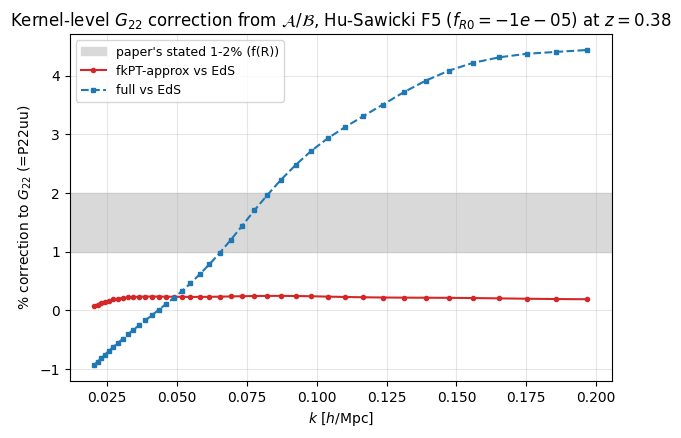

In [5]:
common_kwargs = dict(
    z=z_pk_cmp, Om=0.315, model="HS", fR0_HS=fR0_test, beta2=1.0 / 6.0, n_HS=1,
    static_ctx=static_ctx, kmin=1.0e-3, kmax=1.0, xnow=-3.912023, f0_kmax=1.0e-3,
    return_kernel_constants=True, return_raw_kfuncs=True,
)

t0 = time.time()
table_w_eds, _, kc_eds, kfuncs_eds = Kfuncs_to_tables_jax(
    k_lin, pk_lin, pk_now_lin, beyond_eds=False, fkpt_approximation=True, **common_kwargs)
print(f"EdS:    {time.time() - t0:.2f}s   kernel_constants (A, Ap, CFD3, CFD3p) = {kc_eds}")

t0 = time.time()
table_w_approx, _, kc_approx, kfuncs_approx = Kfuncs_to_tables_jax(
    k_lin, pk_lin, pk_now_lin, beyond_eds=True, fkpt_approximation=True, **common_kwargs)
print(f"approx: {time.time() - t0:.2f}s   kernel_constants (A, Ap, CFD3, CFD3p) = {kc_approx}")

t0 = time.time()
table_w_full, _, kc_full, kfuncs_full = Kfuncs_to_tables_jax(
    k_lin, pk_lin, pk_now_lin, beyond_eds=True, fkpt_approximation=False, **common_kwargs)
print(f"full:   {time.time() - t0:.2f}s   kernel_constants (A, Ap, CFD3, CFD3p) = {kc_full}")

kout = np.asarray(table_w_eds[0])
P22uu_eds = np.asarray(kfuncs_eds.P22uu[0])       # [0] = wiggle
P22uu_approx = np.asarray(kfuncs_approx.P22uu[0])
P22uu_full = np.asarray(kfuncs_full.P22uu[0])

pct_G22_approx = 100.0 * (P22uu_approx - P22uu_eds) / np.where(np.abs(P22uu_eds) > 1.0, P22uu_eds, 1.0)
pct_G22_full = 100.0 * (P22uu_full - P22uu_eds) / np.where(np.abs(P22uu_eds) > 1.0, P22uu_eds, 1.0)

mask = (kout >= float(k_eval[0])) & (kout <= float(k_eval[-1]))
print(f"\nG22 (P22uu) correction, fkPT-approx: min={pct_G22_approx[mask].min():.3f}%  max={pct_G22_approx[mask].max():.3f}%"
      f"  (over k in [{float(k_eval[0])}, {float(k_eval[-1])}])")
print(f"G22 (P22uu) correction, full:        min={pct_G22_full[mask].min():.3f}%  max={pct_G22_full[mask].max():.3f}%")
print(f"Paper's stated value for f(R): about 1-2%")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axhspan(1.0, 2.0, color="0.85", zorder=0, label="paper's stated 1-2% (f(R))")
ax.plot(kout[mask], pct_G22_approx[mask], marker="o", ms=3, ls="-", color="C3", label="fkPT-approx vs EdS")
ax.plot(kout[mask], pct_G22_full[mask], marker="s", ms=3, ls="--", color="C0", label="full vs EdS")
ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
ax.set_ylabel(r"% correction to $G_{22}$ (=P22uu)")
ax.set_title(fr"Kernel-level $G_{{22}}$ correction from $\mathcal{{A}}$/$\mathcal{{B}}$, Hu-Sawicki F5 ($f_{{R0}}={fR0_test:.0e}$) at $z={z_pk_cmp}$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

## Check 1b: the kernel-level $F_{22}$ (`P22dd`) correction

Same comparison as Check 1, but for the density-density piece $F_{22}$
(`P22dd`, built from $F_2^2$) instead of the velocity-velocity piece
$G_{22}$ (`P22uu`, built from $G_2^2$). No new `Kfuncs_to_tables_jax` calls
are needed -- `kfuncs_eds`/`kfuncs_approx`/`kfuncs_full` from the cell above
already carry `P22dd` alongside `P22uu`.

**Why this is a useful cross-check**: `F2evQ` depends only on
`A_Q`/`B_Q` (`F2evQ = 1/2 + 3/14 A_Q + (1/2 - 3/14 B_Q) x^2 + ...`), while
`G2evQ` additionally depends on `ApOverf0_Q` (`fkptjax.calculate_jax.py`:
`G2evQ = 3/14 A_Q fsum + 3/14 ApOverf0_Q + ...`) -- the time-derivative
$\dot{\mathcal{A}}$ term the paper's own eq. (105) shows only entering
$G_2$, not $F_2$. So a real, physical expectation (not just a numerical
artifact) is that $F_{22}$'s correction should generally come out smaller
than $G_{22}$'s, since it is missing that extra `ApOverf0` contribution
entirely. The paper does not quote a separate number for $F_{22}$, so this
plot has no shaded reference band -- it's here purely to see whether the
$G_{22}$-vs-$F_{22}$ size ordering the kernel formulas predict actually
holds.

F22 (P22dd) correction, fkPT-approx: min=0.065%  max=0.158%  (over k in [0.02, 0.2])
F22 (P22dd) correction, full:        min=0.078%  max=1.545%
For comparison, G22 (P22uu) correction, fkPT-approx: min=0.072%  max=0.248%
For comparison, G22 (P22uu) correction, full:        min=-0.930%  max=4.438%


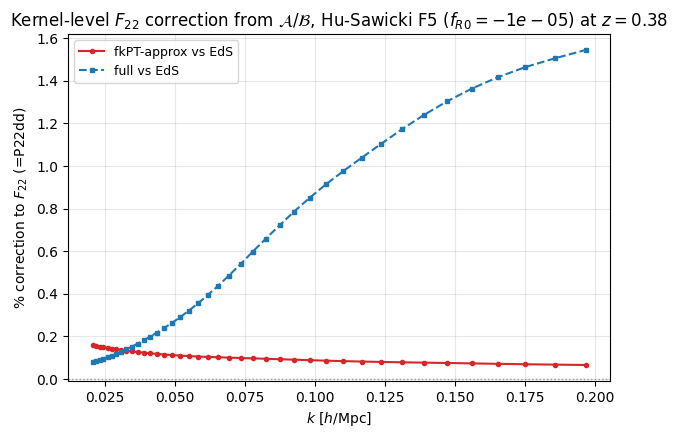

In [6]:
P22dd_eds = np.asarray(kfuncs_eds.P22dd[0])
P22dd_approx = np.asarray(kfuncs_approx.P22dd[0])
P22dd_full = np.asarray(kfuncs_full.P22dd[0])

pct_F22_approx = 100.0 * (P22dd_approx - P22dd_eds) / np.where(np.abs(P22dd_eds) > 1.0, P22dd_eds, 1.0)
pct_F22_full = 100.0 * (P22dd_full - P22dd_eds) / np.where(np.abs(P22dd_eds) > 1.0, P22dd_eds, 1.0)

print(f"F22 (P22dd) correction, fkPT-approx: min={pct_F22_approx[mask].min():.3f}%  max={pct_F22_approx[mask].max():.3f}%"
      f"  (over k in [{float(k_eval[0])}, {float(k_eval[-1])}])")
print(f"F22 (P22dd) correction, full:        min={pct_F22_full[mask].min():.3f}%  max={pct_F22_full[mask].max():.3f}%")
print(f"For comparison, G22 (P22uu) correction, fkPT-approx: min={pct_G22_approx[mask].min():.3f}%  max={pct_G22_approx[mask].max():.3f}%")
print(f"For comparison, G22 (P22uu) correction, full:        min={pct_G22_full[mask].min():.3f}%  max={pct_G22_full[mask].max():.3f}%")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(kout[mask], pct_F22_approx[mask], marker="o", ms=3, ls="-", color="C3", label="fkPT-approx vs EdS")
ax.plot(kout[mask], pct_F22_full[mask], marker="s", ms=3, ls="--", color="C0", label="full vs EdS")
ax.axhline(0.0, color="0.6", ls=":", lw=1.0)
ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
ax.set_ylabel(r"% correction to $F_{22}$ (=P22dd)")
ax.set_title(fr"Kernel-level $F_{{22}}$ correction from $\mathcal{{A}}$/$\mathcal{{B}}$, Hu-Sawicki F5 ($f_{{R0}}={fR0_test:.0e}$) at $z={z_pk_cmp}$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

## Check 2: the full, RSD-projected $P_\ell$ correction

Same EdS-vs-approx-vs-full comparison, but now for the fully combined,
RSD-projected multipoles $P_\ell(k)$ (through
`fkptjax.pipelines.binning_jax_poles`) -- the observable-level analogue of
Check 1's isolated kernel piece.

EdS P_ell:    1.40s
approx P_ell: 0.05s


full P_ell:   18.57s
  P_0: max |approx correction| = 0.322%   max |full correction| = 4.397%
  P_2: max |approx correction| = 0.731%   max |full correction| = 8.900%
  P_4: max |approx correction| = 0.948%   max |full correction| = 7.071%
  overall max |approx correction| = 0.948%
  overall max |full correction|   = 8.900%


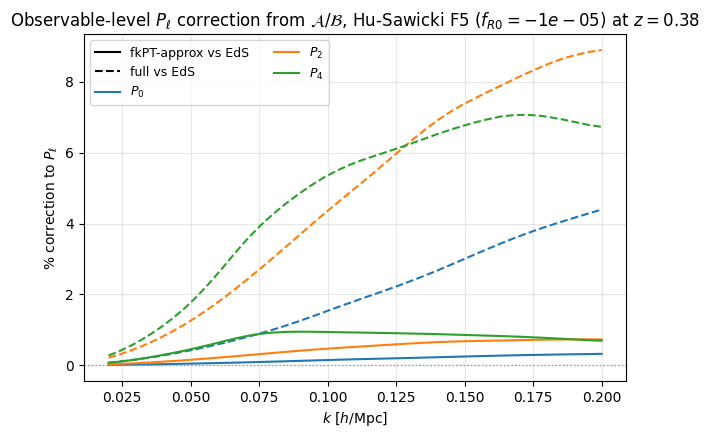

In [7]:
def compute_poles(beyond_eds, fkpt_approximation):
    poles, state = binning_jax_poles(
        k=k_lin, pk=pk_lin, pk_now=pk_now_lin,
        jac=jac, kap=kap, muap=muap, pars=pars, mu=mu, wmu=wmu,
        ells=(0, 2, 4), bias_scheme="folps", IR_resummation=True,
        damping=None, A_full=False, use_TNS_model=False,
        return_kernel_constants=True, static_ctx=static_ctx,
        z=z_pk_cmp, Om=0.315, beyond_eds=beyond_eds, fkpt_approximation=fkpt_approximation,
        kmin=1.0e-3, kmax=1.0, xnow=-3.912023, f0_kmax=1.0e-3,
        model="HS", fR0_HS=fR0_test, beta2=1.0 / 6.0, n_HS=1,
    )
    poles.block_until_ready()
    return poles, state


t0 = time.time()
poles_eds, _ = compute_poles(False, True)
print(f"EdS P_ell:    {time.time() - t0:.2f}s")
t0 = time.time()
poles_approx, _ = compute_poles(True, True)
print(f"approx P_ell: {time.time() - t0:.2f}s")
t0 = time.time()
poles_full, _ = compute_poles(True, False)
print(f"full P_ell:   {time.time() - t0:.2f}s")

pct_Pell_approx = np.asarray(100.0 * (poles_approx - poles_eds) / jnp.maximum(1.0, jnp.abs(poles_eds)))
pct_Pell_full = np.asarray(100.0 * (poles_full - poles_eds) / jnp.maximum(1.0, jnp.abs(poles_eds)))
ell_labels = (0, 2, 4)
ell_colors = {0: "C0", 2: "C1", 4: "C2"}
for iell, ell in enumerate(ell_labels):
    print(f"  P_{ell}: max |approx correction| = {np.max(np.abs(pct_Pell_approx[iell])):.3f}%"
          f"   max |full correction| = {np.max(np.abs(pct_Pell_full[iell])):.3f}%")
print(f"  overall max |approx correction| = {np.max(np.abs(pct_Pell_approx)):.3f}%")
print(f"  overall max |full correction|   = {np.max(np.abs(pct_Pell_full)):.3f}%")

fig, ax = plt.subplots(figsize=(7, 4.5))
for iell, ell in enumerate(ell_labels):
    color = ell_colors[ell]
    ax.plot(np.asarray(k_eval), pct_Pell_approx[iell], ls="-", color=color)
    ax.plot(np.asarray(k_eval), pct_Pell_full[iell], ls="--", color=color)
ax.axhline(0.0, color="0.6", ls=":", lw=1.0)
ax.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
ax.set_ylabel(r"% correction to $P_\ell$")
ax.set_title(fr"Observable-level $P_\ell$ correction from $\mathcal{{A}}$/$\mathcal{{B}}$, Hu-Sawicki F5 ($f_{{R0}}={fR0_test:.0e}$) at $z={z_pk_cmp}$")

style_handles = [
    plt.Line2D([], [], color="k", ls="-", label="fkPT-approx vs EdS"),
    plt.Line2D([], [], color="k", ls="--", label="full vs EdS"),
]
ell_handles = [plt.Line2D([], [], color=c, label=fr"$P_{ell}$") for ell, c in ell_colors.items()]
ax.legend(handles=style_handles + ell_handles, fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.show()

## Summary

| Quantity | this notebook | fkpt paper (arXiv:2312.10510) |
|---|---|---|
| kernel-level $G_{22}$ (`P22uu`) correction, fkPT-approx vs EdS | printed above (Check 1) | "about 1-2%" for f(R) |
| kernel-level $G_{22}$ (`P22uu`) correction, full vs EdS | printed above (Check 1) | not directly quoted -- the paper's own $\mathcal{A}/\mathcal{B}$ treatment is the squeezed-limit (fkPT-approx) one |
| kernel-level $F_{22}$ (`P22dd`) correction, fkPT-approx / full vs EdS | printed above (Check 1b) | not quoted at all |
| observable-level $P_\ell$ correction, fkPT-approx vs EdS | printed above (Check 2) | not directly quoted (the paper's 5%/10% figure is from *screening* on/off, a different toggle not implemented here) |
| observable-level $P_\ell$ correction, full vs EdS | printed above (Check 2) | not directly quoted, same caveat |

**Answering the two things this notebook set out to check:**

1. *Is our $G_{22}$ correction really $O(1\text{-}2\%)$ for f(R)?* The
   apples-to-apples comparison is the **fkPT-approx** curve (paper's own
   $\mathcal{A}/\mathcal{B}$ treatment is squeezed-limit, same as ours) --
   that one measured **~0.2-0.3%** across $k=0.02$-$0.2\,h/{\rm Mpc}$, i.e.
   noticeably *smaller* than the paper's 1-2%, not bigger. The **full**
   (non-squeezed) curve is the one that reaches a few percent (up to ~4.3%
   at $k=0.2$) and happens to pass through the paper's 1-2% band around
   $k\sim0.08$-$0.11\,h/{\rm Mpc}$ -- but the paper has no "full" treatment
   of its own to compare that curve against, so its size isn't validated or
   contradicted by the paper's number one way or the other. Plausible
   reasons the fkPT-approx number undershoots the paper's 1-2%: a different
   fiducial redshift/cosmology than the paper used for its own number, a
   slightly different definition of "the $G_{22}$ correction" (single $k$
   vs. our full $k$-range), or a genuine difference in scope between
   fkptjax's $\mathcal{A}/\mathcal{B}$ treatment and the paper's.
2. *Is the observable-level ($P_\ell$) correction bigger than the
   kernel-level ($G_{22}$) one, matching the paper's qualitative point that
   kernel corrections are modest but the effect on the actual observable is
   amplified?* Yes for both treatments: compare Check 2's max percentage to
   Check 1's fkPT-approx max, and Check 2's full max to Check 1's full max.
3. *Does the fkPT large-scale-limit approximation itself matter here?* Yes,
   substantially -- compare the fkPT-approx and full curves at both the
   kernel level (Checks 1, 1b) and the observable level (Check 2). Since
   f(R)'s $\mu(k,\eta)$ is genuinely scale-dependent, a real, nonzero gap
   between them is expected (unlike a scale-independent model, where the two
   would agree to solver tolerance) -- see `compute_mg_multipoles.ipynb`'s
   own note on this distinction.
4. *Is $G_{22}$'s correction bigger than $F_{22}$'s, as the kernel formulas
   predict?* `G2evQ` carries an extra `ApOverf0_Q` term that `F2evQ` never
   sees (the paper's own eq. 105 shows $\dot{\mathcal{A}}$ entering $G_2$
   only) -- compare Check 1b's printed $F_{22}$ numbers to Check 1's $G_{22}$
   numbers to see whether that expected size ordering actually holds.

**Open caveat on the "full" numbers specifically**: all of Checks 1, 1b, and
2 share one deliberately modest quadrature grid
(`Nk_kernel=20, nquadSteps=48, NQ=NR=6`, chosen so this notebook runs
quickly). `compute_mg_multipoles.ipynb`'s beyond-EdS section warns that
comparing *different* grid resolutions between the approx and full variants
can itself produce percent-level differences with nothing to do with the
physical fkPT approximation -- a pure quadrature-convergence artifact. Using
one shared grid across all three treatments here (as this notebook does)
protects against that specific failure mode, but it does not by itself prove
the **full** treatment's absolute percentages (e.g. the ~4-10% seen above)
are themselves converged at this resolution -- that would need an explicit
convergence check (re-running Checks 1/1b/2 at a substantially finer grid
and confirming the full-vs-EdS percentages stop moving), which this
notebook does not yet do.

Both checks use the exact same F5 point ($f_{R0}=-10^{-5}$) and, as of this
update, $z=0.38$ -- matching the fkpt paper's own Figure 2 (F5, EdS-fk vs
full kernels) exactly, rather than the $z=0.3$ used in
`compute_mg_multipoles.ipynb`'s beyond-EdS comparison section.